# 09 · Effect sizes, classification, harmonization

**SpectralBrain tutorial series — notebook 9 of 10.** (Previous: cohorts & vertex-wise statistics.)

Vertex-wise maps say *where* shapes differ. This notebook quantifies *how much*,
*how reliably*, and *how to compare descriptors* as biomarkers, then handles the
practical curse of multi-site data: scanner batch effects.

### Learning objectives
1. Cross-validate a descriptor as a classifier and compare two descriptors' AUCs
   with DeLong's test.
2. Put bias-corrected bootstrap confidence intervals on an estimate.
3. Measure test-retest reliability with the intraclass correlation coefficient.
4. Detect and remove multi-site batch effects with ComBat.

> As in notebook 8, the feature cohort below is **synthetic, built to exercise the
> methods**, with a planted group effect and a planted site effect. No clinical
> claim is implied.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import spectralbrain.statistics as st

rng = np.random.default_rng(7)
n_per, p = 24, 10
labels = np.r_[np.zeros(n_per), np.ones(n_per)].astype(int)   # 0 = control, 1 = patient
sites  = np.r_[np.tile([0, 1], n_per)].astype(int)            # two scanners, interleaved

X = rng.normal(size=(2 * n_per, p))                           # p descriptor features
X[labels == 1, :3] += 0.9                                     # group effect in features 0–2
print(f"synthetic feature cohort: {X.shape}  ({n_per} controls + {n_per} patients, 2 sites)")

synthetic feature cohort: (48, 10)  (24 controls + 24 patients, 2 sites)


## 1. Is the descriptor a biomarker? Cross-validated classification

`classify` runs a cross-validated classifier (SVM, logistic, or random forest) and
reports accuracy and AUC with their fold standard deviations, plus per-feature
importance. AUC is the headline number: 0.5 is chance, 1.0 is perfect separation.

model: logistic
accuracy: 0.815 ± 0.114
AUC     : 0.886 ± 0.075


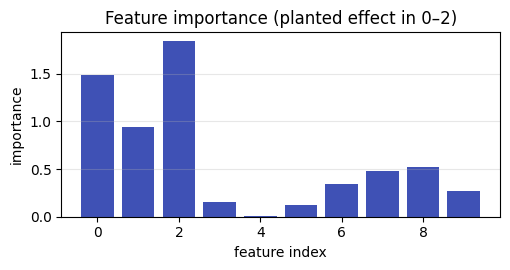

In [2]:
res = st.classify(X, labels, model="logistic", n_folds=5, seed=0)
print(f"model: {res.model_name}")
print(f"accuracy: {res.accuracy:.3f} ± {res.accuracy_std:.3f}")
print(f"AUC     : {res.auc:.3f} ± {res.auc_std:.3f}")

fig, ax = plt.subplots(figsize=(5.2, 2.8))
ax.bar(range(p), res.feature_importance, color="#3f51b5")
ax.set_xlabel("feature index"); ax.set_ylabel("importance")
ax.set_title("Feature importance (planted effect in 0–2)"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 2. Comparing two descriptors: DeLong's test

Suppose two descriptors each give a score for separating patients from controls,
and you want to know whether one is a *significantly* better discriminator. The
**DeLong test** compares two correlated ROC curves analytically (no bootstrap
needed). It returns both AUCs and a p-value for their difference.

In [3]:
score_good = X[:, 0]                          # a discriminative feature
score_weak = X[:, 7]                          # a non-discriminative feature
auc_new, auc_ref, p_val = st.auc_comparison_delong(labels, score_good, score_weak)
print(f"AUC (discriminative feature): {auc_new:.3f}")
print(f"AUC (weak feature)          : {auc_ref:.3f}")
print(f"DeLong p-value for the difference: {p_val:.4f}")

AUC (discriminative feature): 0.830
AUC (weak feature)          : 0.394
DeLong p-value for the difference: 0.0000


## 3. How certain is that number? Bootstrap intervals

A point estimate without an interval is hard to trust. `bootstrap_ci` resamples
the data to put a confidence interval on any statistic; the **bias-corrected and
accelerated (BCa)** method corrects for skew and bias and is the right default.
`bootstrap_paired_difference` does the same for a paired contrast between two
descriptors.

In [4]:
est, lo, hi = st.bootstrap_ci(score_good[labels == 1], np.mean,
                              n_bootstrap=5000, ci=0.95, method="bca")
print(f"patient mean of discriminative feature: {est:.3f}  (95% BCa CI [{lo:.3f}, {hi:.3f}])")

diff, dlo, dhi = st.bootstrap_paired_difference(X[:, 0], X[:, 1], n_bootstrap=5000, seed=0)
print(f"paired difference feature0 − feature1 : {diff:.3f}  (95% CI [{dlo:.3f}, {dhi:.3f}])")

patient mean of discriminative feature: 0.686  (95% BCa CI [0.219, 0.990])
paired difference feature0 − feature1 : -0.119  (95% CI [-0.479, 0.224])


## 4. Would it replicate? Intraclass correlation

A biomarker is useless if it changes when you rescan the same person. The
**intraclass correlation coefficient (ICC)** measures test-retest reliability:
1.0 is perfect, below ~0.5 is poor. We simulate a retest by adding measurement
noise and compute ICC for a reliable and an unreliable feature.

In [5]:
test = X[:, 0]
retest_good = test + rng.normal(0, 0.2, test.shape)      # small noise -> reliable
retest_poor = test + rng.normal(0, 1.5, test.shape)      # large noise -> unreliable
print(f"ICC (low noise) : {st.compute_icc(test, retest_good):.3f}")
print(f"ICC (high noise): {st.compute_icc(test, retest_poor):.3f}")

ICC (low noise) : 0.981
ICC (high noise): 0.605


## 5. Multi-site reality: detecting and removing batch effects

Pooling scanners introduces **site effects** that mimic or mask biology.
`batch_effect_scan` flags which features differ by site; `harmonize_combat`
removes the site shift with empirical-Bayes ComBat (and `harmonize_combat_gam`
adds non-linear age modelling). We add a site offset, detect it, harmonise, and
confirm it is gone.

In [6]:
Xs = X.copy()
Xs[sites == 1] += 2.0                              # scanner 1 reads systematically higher

before = st.batch_effect_scan({f"f{i}": Xs[:, i] for i in range(p)}, sites)
n_flagged_before = sum(1 for v in before.values() if v.get("significant", False))
print(f"features with a detected site effect BEFORE harmonisation: {n_flagged_before}/{p}")

hr = st.harmonize_combat(Xs, sites)
Xh = hr.data_harmonized
after = st.batch_effect_scan({f"f{i}": Xh[:, i] for i in range(p)}, sites)
n_flagged_after = sum(1 for v in after.values() if v.get("significant", False))
print(f"features with a detected site effect AFTER  harmonisation: {n_flagged_after}/{p}")
print(f"\nmean per-site value of feature 0 — before: "
      f"{Xs[sites==0,0].mean():.2f}/{Xs[sites==1,0].mean():.2f}, "
      f"after: {Xh[sites==0,0].mean():.2f}/{Xh[sites==1,0].mean():.2f}")

features with a detected site effect BEFORE harmonisation: 0/10


[06/09/26 02:13:03] INFO     ComBat harmonization: 48 samples x 10 features, 2 sites.

features with a detected site effect AFTER  harmonisation: 0/10

mean per-site value of feature 0 — before: 0.34/2.08, after: 1.19/1.23


**When *not* to use ComBat.** ComBat assumes each site has enough subjects to
estimate its effect and that site is not perfectly confounded with the variable of
interest. If one scanner has a handful of subjects, or if site and (say) field
strength are perfectly aligned, ComBat will either fail or silently remove real
signal. In those cases a model with site as an explicit batch/random effect
(notebook 10's hierarchical and normative models) is safer than post-hoc
harmonisation.

## Exercises

1. **Model choice.** Re-run `classify` with `model='svm'` and `'random_forest'`.
   Does AUC change? Which features does each rank highest?
2. **Honest AUC.** Compare `score_good` against a *pure noise* reference in the
   DeLong test. Is the difference significant, and does the p-value make sense?
3. **Percentile vs BCa.** Recompute the bootstrap CI with `method='percentile'`
   and compare to BCa. When does the correction matter most?
4. **Reliability threshold.** Sweep the retest noise level and find where ICC drops
   below 0.5. How noisy can a descriptor be before it stops being a biomarker?
5. **GAM harmonisation.** Add a synthetic "age" covariate with a non-linear trend
   and harmonise with `harmonize_combat_gam`, passing age as a covariate. Does it
   preserve the age trend while removing the site shift?


## What's next

The finale. **Notebook 10** moves to **Bayesian** spectral analysis: sparse
horseshoe regression to pick which descriptor features matter, robust group
comparison with a region of practical equivalence, and a Gaussian-process
normative model that turns a healthy reference into per-subject deviation
z-scores, all wired to the visualization stack. It ties the whole series into one
end-to-end workflow.
